In [4]:
import os
import random
import subprocess
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2
import tifffile as tiff

import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                      concatenate, Conv2DTranspose,
                                      BatchNormalization, Activation)
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [5]:
dataset_path = '/kaggle/input/datasets/saharamrr/satalitedataset/data'
dataset_dir = os.listdir(dataset_path)
print(f'the data contains {dataset_dir}')

the data contains ['labels', 'images']


# **STEP 1: Data Alignment (Pairing Images with Labels)**

## What is Data Alignment?
- **Satellite Dataset Structure**: TIF files (images) and PNG files (ground truth labels)
- **Goal**: Ensure each satellite image has a matching label
- **Action**: Find common filenames between folders
- **Why**: Missing pairs cause training errors

In [6]:
image_dir = os.path.join(dataset_path, 'images')
mask_dir = os.path.join(dataset_path, 'labels')

image_paths = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))

images = [tiff.imread(p) for p in image_paths]
masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in mask_paths]

print("Images found:", len(image_paths))
print("Labels found:", len(mask_paths))

if len(images) > 0:
    print(f"Sample Image Shape: {images[0].shape}")
    print(f"Sample Mask Shape: {masks[0].shape}")

Images found: 306
Labels found: 456
Sample Image Shape: (128, 128, 12)
Sample Mask Shape: (128, 128)


In [7]:
image_names = set([os.path.splitext(os.path.basename(f))[0] for f in image_paths])
label_names = set([os.path.splitext(os.path.basename(f))[0] for f in mask_paths])

print("Images without labels:", len(image_names - label_names))
print("Labels without images:", len(label_names - image_names))

Images without labels: 0
Labels without images: 150


In [8]:
common_names = sorted(list(image_names & label_names))
print("Total valid pairs:", len(common_names))

Total valid pairs: 306


In [9]:
clean_image_paths = [os.path.join(image_dir, name + ".tif") for name in common_names]
clean_label_paths = [os.path.join(mask_dir, name + ".png") for name in common_names]

print("Clean images list size:", len(clean_image_paths))
print("Clean labels list size:", len(clean_label_paths))

Clean images list size: 306
Clean labels list size: 306


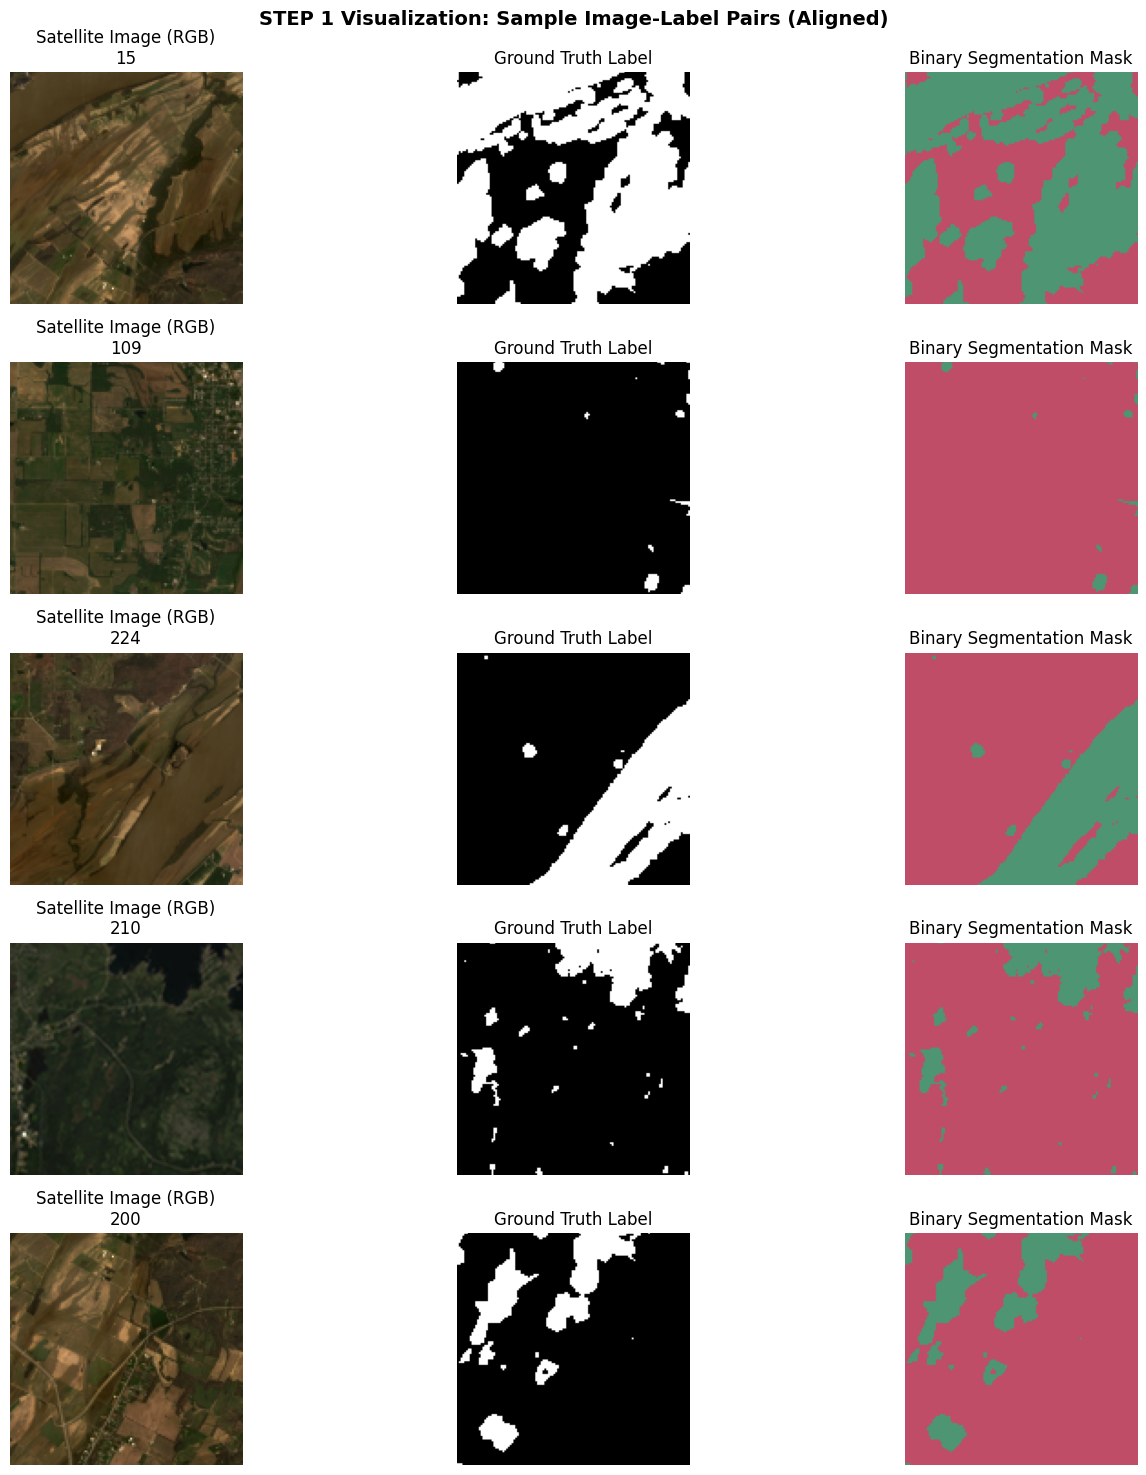

In [10]:
sample_indices = random.sample(range(len(common_names)), min(5, len(common_names)))

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 3*len(sample_indices)))
fig.suptitle('STEP 1 Visualization: Sample Image-Label Pairs (Aligned)', fontsize=14, fontweight='bold')

for row, idx in enumerate(sample_indices):
    name = common_names[idx]
    img_path = os.path.join(image_dir, name + ".tif")
    label_path = os.path.join(mask_dir, name + ".png")
    
    img = tiff.imread(img_path)
    rgb_img = np.stack([img[:,:,3], img[:,:,2], img[:,:,1]], axis=-1)
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
    
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    
    axes[row, 0].imshow(rgb_img)
    axes[row, 0].set_title(f'Satellite Image (RGB)\n{name}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(label, cmap='gray')
    axes[row, 1].set_title(f'Ground Truth Label')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(label > 0, cmap='RdYlGn', alpha=0.7)
    axes[row, 2].set_title(f'Binary Segmentation Mask')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('step1_data_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

# **STEP 2: Normalization**

- **Raw TIF values**: Often 0 to 10,000+ (different range for each band)
- **After normalization**: All bands scaled to [0, 1]
- **Method**: Min-Max scaling: (x - min) / (max - min)

In [11]:
images_all = [tiff.imread(p) for p in clean_image_paths]
masks_all = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in clean_label_paths]

print(f"Loaded {len(images_all)} images and {len(masks_all)} masks.")

Loaded 306 images and 306 masks.


In [12]:
band_names = ['Coastal Aerosol','Blue','Green','Red','NIR','SWIR1','SWIR2',
              'QA Band','Merit DEM','Copernicus DEM','ESA WorldCover','Water Prob']
num_bands = 12

global_min = np.full(num_bands, np.inf)
global_max = np.full(num_bands, -np.inf)

for idx, img in enumerate(images_all):
    img_data = img.astype(np.float32)
    for b in range(num_bands):
        band_data = img_data[:, :, b]
        if band_data.min() < global_min[b]:
            global_min[b] = band_data.min()
        if band_data.max() > global_max[b]:
            global_max[b] = band_data.max()

band_stats = pd.DataFrame({
    'Band': [f'{i+1}: {name}' for i, name in enumerate(band_names)],
    'Min': global_min,
    'Max': global_max,
    'Range': global_max - global_min
})

print("BAND-WISE MIN/MAX STATISTICS (Across All Images)")
print(band_stats.to_string(index=False))

band_stats_dict = {
    'min': global_min,
    'max': global_max,
    'names': band_names
}

BAND-WISE MIN/MAX STATISTICS (Across All Images)
              Band     Min     Max   Range
1: Coastal Aerosol -1393.0  6568.0  7961.0
           2: Blue -1169.0  9659.0 10828.0
          3: Green  -722.0 11368.0 12090.0
            4: Red  -684.0 12041.0 12725.0
            5: NIR  -412.0 15841.0 16253.0
          6: SWIR1  -335.0 15252.0 15587.0
          7: SWIR2  -258.0 14647.0 14905.0
        8: QA Band    64.0   255.0   191.0
      9: Merit DEM -9999.0  4245.0 14244.0
10: Copernicus DEM     8.0  4287.0  4279.0
11: ESA WorldCover    10.0   100.0    90.0
    12: Water Prob     0.0   111.0   111.0


In [13]:
# Normalize each image band using global min/max
images_norm = np.zeros((len(images_all), 128, 128, num_bands), dtype=np.float32)

for i, img in enumerate(images_all):
    img_data = img.astype(np.float32)
    for b in range(num_bands):
        band_min = band_stats_dict['min'][b]
        band_max = band_stats_dict['max'][b]
        denom = band_max - band_min
        if denom > 0:
            images_norm[i, :, :, b] = (img_data[:, :, b] - band_min) / denom
        else:
            images_norm[i, :, :, b] = 0.0

# Also convert masks to numpy array
# إعادة تحميل الـ masks بدون قسمة على 255
masks_all = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in clean_label_paths]
masks_all_arr = np.array(masks_all, dtype=np.float32)  # مش /255

# تحقق
print(f"Unique values: {np.unique(masks_all_arr)}")  # المفروض [0. 1.]
print(f"Water ratio: {masks_all_arr.mean():.4f}")
print(f"images_norm shape: {images_norm.shape}")
print(f"masks_all_arr shape: {masks_all_arr.shape}")
print(f"Pixel value range: [{images_norm.min():.3f}, {images_norm.max():.3f}]")

Unique values: [0. 1.]
Water ratio: 0.2598
images_norm shape: (306, 128, 128, 12)
masks_all_arr shape: (306, 128, 128)
Pixel value range: [0.000, 1.000]


In [53]:
def dice_coef(y_true, y_pred, smooth=100):
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [54]:
from tensorflow.keras import regularizers # أضف هذا السطر في بداية الكود

def build_vgg16_unet(input_shape):
    inputs = Input(input_shape)
    vgg16 = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    # ... (أكواد الحصول على skip connections كما هي) ...
    s1 = vgg16.get_layer("block1_conv2").output
    s2 = vgg16.get_layer("block2_conv2").output
    s3 = vgg16.get_layer("block3_conv3").output
    s4 = vgg16.get_layer("block4_conv3").output
    bridge = vgg16.get_layer("block5_conv3").output

    def decoder_block(input_tensor, skip_features, num_filters):
        reg = regularizers.l2(1e-4)
        
        # جرب num_filters بدلاً من num_filters // 2
        x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input_tensor)
        x = concatenate([x, skip_features])
        
        x = Conv2D(num_filters, 3, padding="same", kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        
        x = tf.keras.layers.Dropout(0.4)(x) # خفف الـ Dropout قليلاً
        
        x = Conv2D(num_filters, 3, padding="same", kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        return x

    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, (1, 1), padding="same", activation="sigmoid")(d4)
    model = Model(inputs, outputs, name="VGG16_UNet")
    return model


In [55]:
print(images_norm.shape)        # expect (306, 128, 128, 12)
print(masks_all_arr.shape)      # expect (306, 128, 128)

(306, 128, 128, 12)
(306, 128, 128)


In [56]:
images_3ch = images_norm[:, :, :, [3, 2, 1]]

all_indices = np.arange(len(images_3ch))
train_indices, temp_indices = train_test_split(all_indices, test_size=0.3, random_state=42)
val_indices, test_indices   = train_test_split(temp_indices, test_size=0.5, random_state=42)

# أعد الـ split
train_data = {'images': images_3ch[train_indices], 'masks': masks_all_arr[train_indices]}
val_data   = {'images': images_3ch[val_indices],   'masks': masks_all_arr[val_indices]}
test_data  = {'images': images_3ch[test_indices],  'masks': masks_all_arr[test_indices]}

train_data['masks'] = np.expand_dims(train_data['masks'], axis=-1)
val_data['masks']   = np.expand_dims(val_data['masks'],   axis=-1)
test_data['masks']  = np.expand_dims(test_data['masks'],  axis=-1)

print(f"Train masks max: {train_data['masks'].max()}")  # المفروض 1.0

Train masks max: 1.0


In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import numpy as np

def augment(image, mask):
    """
    دالة Augmentation متقدمة لتقليل الـ Overfitting
    """

    # 1. Random horizontal flip (موجود بالفعل)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # 2. Random vertical flip (موجود بالفعل)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # 3. Random rotation (جديد) - تدوير عشوائي
    #    هذه التقنية تحتاج لضبط بعناية مع الـ masks
    rotation_factor = tf.random.uniform([], -0.1, 0.1)  # تدوير خفيف بنسبة 10%
    image = tf.image.rot90(image, k=tf.cast(rotation_factor * 4, tf.int32))
    mask = tf.image.rot90(mask, k=tf.cast(rotation_factor * 4, tf.int32))

    # 4. Random zoom (جديد) - تكبير/تصغير عشوائي
    #    سنستخدم `tf.image.resize` مع crop
    scales = tf.random.uniform([], 0.8, 1.2) # تكبير أو تصغير بين 80% و 120%
    new_h = tf.cast(tf.cast(128, tf.float32) * scales, tf.int32)
    new_w = tf.cast(tf.cast(128, tf.float32) * scales, tf.int32)
    
    image_resized = tf.image.resize(image, (new_h, new_w))
    mask_resized = tf.image.resize(mask, (new_h, new_w), method='nearest')
    
    image = tf.image.resize_with_crop_or_pad(image_resized, 128, 128)
    mask = tf.image.resize_with_crop_or_pad(mask_resized, 128, 128)

    # 5. Random brightness (موجود ولكن بقيمة أكبر قليلاً)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.clip_by_value(image, 0, 1)

    # 6. Random contrast (جديد)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0, 1)


    return image, mask

In [63]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam

# 1. تعريف الدوال أولاً (Metrics & Loss)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def binary_accuracy(y_true, y_pred):
    return K.mean(K.equal(y_true, K.round(y_pred)))

def total_loss(y_true, y_pred):
    # دمج BCE مع Dice Loss
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# 2. إعداد الموديل وتجميد الـ Encoder
# تأكد أن اسم الـ variable للموديل هو 'model' كما في كودك
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
base_model.trainable = False 

# (هنا يفترض أن يكون كود بناء الـ Decoder الخاص بك قد تم تنفيذه)

# 3. الـ Compile (الآن total_loss معرفة ولن يحدث خطأ)
model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), 
    loss=total_loss,
    metrics=[binary_accuracy, dice_coef]
)

# 4. تجهيز الـ Masks (تأكد من تنفيذ هذه الخطوة على بياناتك)
train_data['masks'] = np.array(train_data['masks']).astype('float32')
if train_data['masks'].max() > 1.0:
    train_data['masks'] /= 255.0
train_data['masks'] = (train_data['masks'] > 0.5).astype('float32')

val_data['masks'] = np.array(val_data['masks']).astype('float32')
if val_data['masks'].max() > 1.0:
    val_data['masks'] /= 255.0
val_data['masks'] = (val_data['masks'] > 0.5).astype('float32')

# 5. البدء في التدريب
history = model.fit(
    train_data['images'],
    train_data['masks'],
    validation_data=(val_data['images'], val_data['masks']),
    epochs=50,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max',
                                        patience=15, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coef', mode='max',
                                              factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - binary_accuracy: 0.9229 - dice_coef: 0.7885 - loss: 0.5605 - val_binary_accuracy: 0.7308 - val_dice_coef: 0.5836 - val_loss: 1.5904 - learning_rate: 1.0000e-04
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - binary_accuracy: 0.9339 - dice_coef: 0.8070 - loss: 0.5169 - val_binary_accuracy: 0.8264 - val_dice_coef: 0.6237 - val_loss: 0.9642 - learning_rate: 1.0000e-04
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - binary_accuracy: 0.9345 - dice_coef: 0.8127 - loss: 0.5097 - val_binary_accuracy: 0.8471 - val_dice_coef: 0.5404 - val_loss: 0.9591 - learning_rate: 1.0000e-04
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - binary_accuracy: 0.9384 - dice_coef: 0.8185 - loss: 0.4914 - val_binary_accuracy: 0.7711 - val_dice_coef: 0.4374 - val_loss: 1.1864 - learning_rate: 1.0000e-04
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 293ms/step - binary_accuracy: 0.9356 - dice_coef: 0.8175 - loss: 0.4978 - val_binary_accuracy: 0.8802 - v

In [66]:
# فك التجميد
base_model.trainable = True

# إعادة الـ Compile بـ Learning Rate أصغر بكثير
model.compile(
    optimizer=Adam(learning_rate=1e-6, clipnorm=1.0), 
    loss=total_loss,
    metrics=[binary_accuracy, dice_coef]
)

# تدريب لـ 20 Epoch إضافية ببطء شديد
history_fine = model.fit(
    train_data['images'], train_data['masks'],
    validation_data=(val_data['images'], val_data['masks']),
    epochs=20,
    batch_size=16,
    callbacks=callbacks # نفس الـ callbacks السابقة
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - binary_accuracy: 0.9694 - dice_coef: 0.9016 - loss: 0.3159 - val_binary_accuracy: 0.9097 - val_dice_coef: 0.7624 - val_loss: 0.6411 - learning_rate: 1.0000e-06
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - binary_accuracy: 0.9693 - dice_coef: 0.9018 - loss: 0.3157 - val_binary_accuracy: 0.9097 - val_dice_coef: 0.7620 - val_loss: 0.6411 - learning_rate: 1.0000e-06
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step - binary_accuracy: 0.9694 - dice_coef: 0.9018 - loss: 0.3156 - val_binary_accuracy: 0.9118 - val_dice_coef: 0.7692 - val_loss: 0.6236 - learning_rate: 1.0000e-06
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - binary_accuracy: 0.9692 - dice_coef: 0.9014 - loss: 0.3164 - val_binary_accuracy: 0.9110 - val_dice_coef: 0.7663 - val_loss: 0.6311 - learning_rate: 1.0000e-06
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - binary_accuracy: 0.9694 - dice_coef: 0.9019 - loss: 0.3158 - val_binary_accuracy: 0.9102 - v

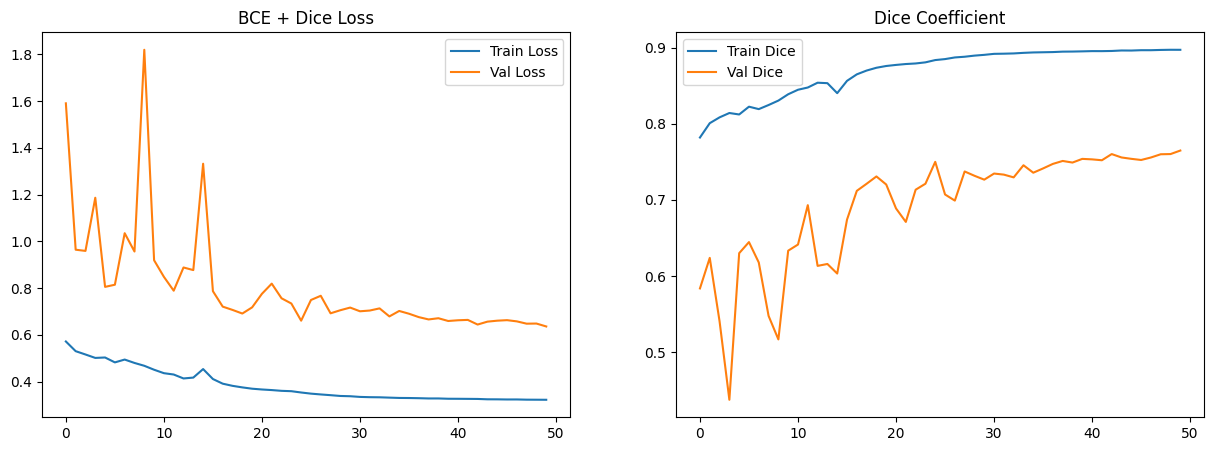

In [75]:
def plot_history(history):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('BCE + Dice Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['dice_coef'], label='Train Dice')
    plt.plot(history.history['val_dice_coef'], label='Val Dice')
    plt.title('Dice Coefficient')
    plt.legend()
    
    plt.show()

plot_history(history)

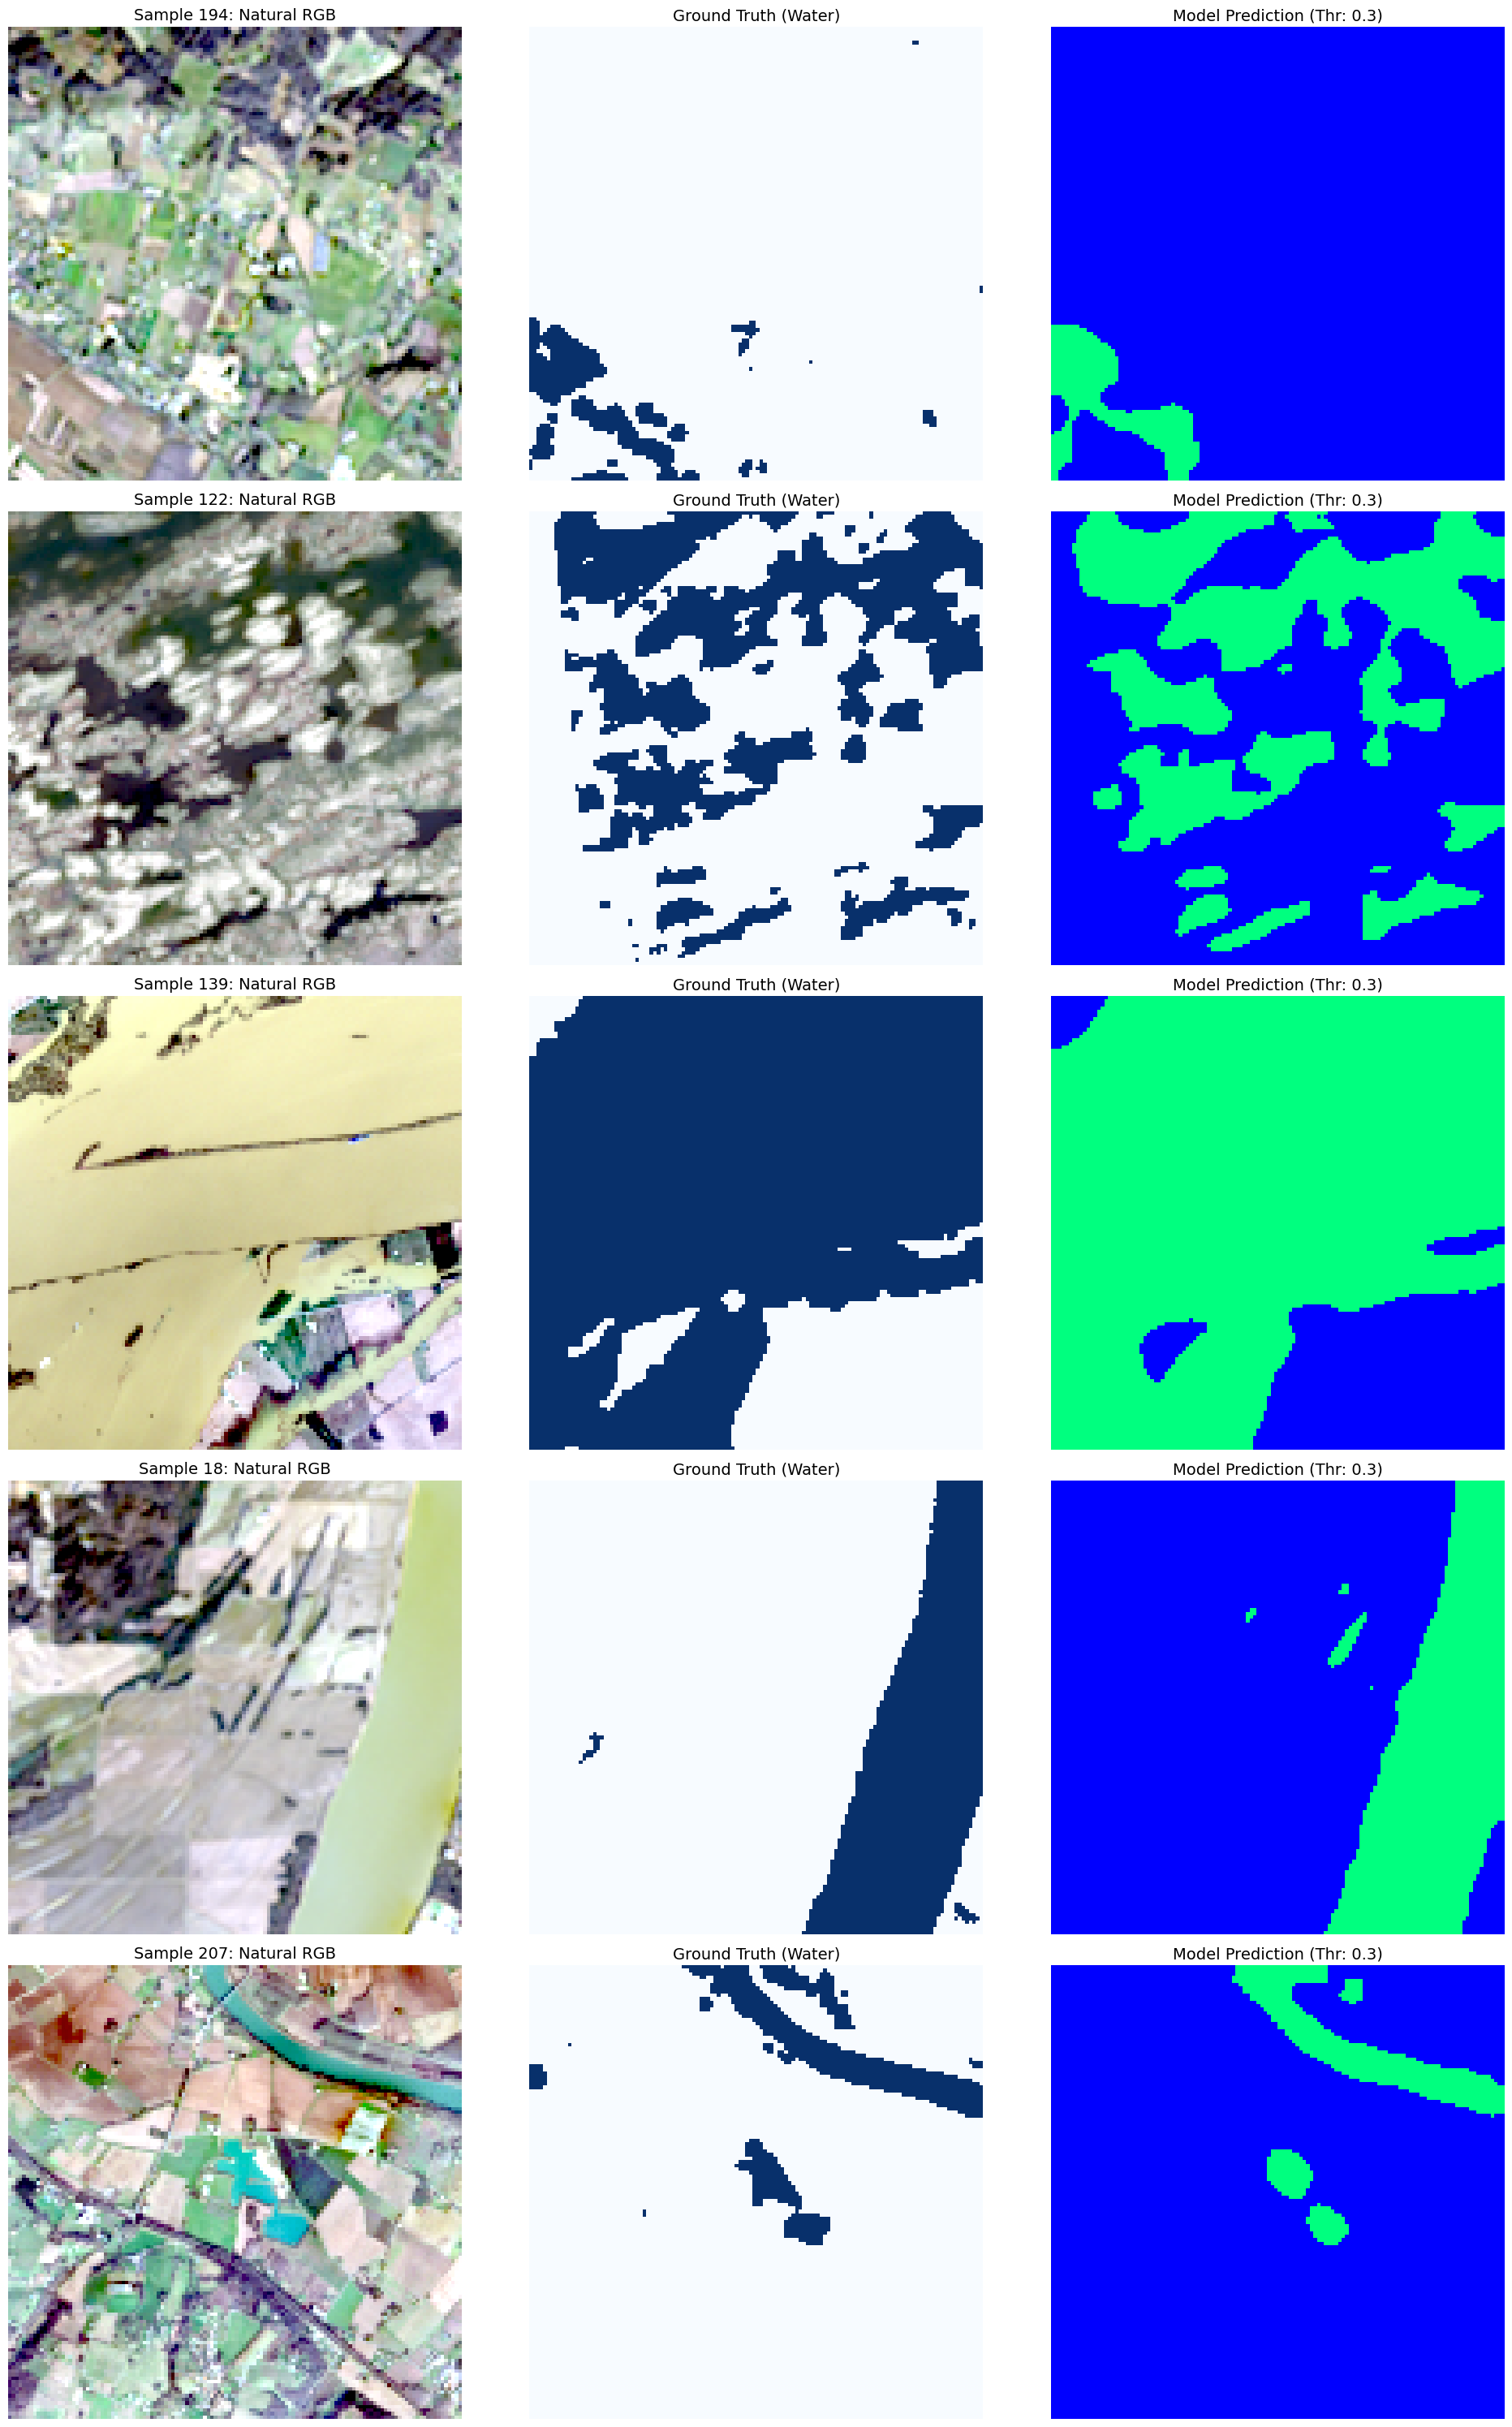

In [76]:
def visualize_five_samples(model, images_array, masks_array, n=5, gamma=0.6, threshold=0.5):
    indices = np.random.choice(len(images_array), n, replace=False)
    plt.figure(figsize=(20, n * 6))
    
    for i, idx in enumerate(indices):
        img_raw = images_array[idx].copy().astype(np.float32)
        mask = masks_array[idx].squeeze()
        
        pred = model.predict(np.expand_dims(images_array[idx], axis=0), verbose=0)
        pred_mask = (pred.squeeze() > threshold).astype(np.float32)
        
        img_fixed = np.zeros_like(img_raw)
        for ch in range(3):
            ch_min, ch_max = np.percentile(img_raw[:,:,ch], (2, 98))
            if ch_max - ch_min > 0:
                img_fixed[:,:,ch] = np.clip((img_raw[:,:,ch] - ch_min) / (ch_max - ch_min), 0, 1)
            else:
                img_fixed[:,:,ch] = img_raw[:,:,ch]
        
        img_final = np.power(img_fixed, gamma)
        
        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(img_final)
        plt.title(f"Sample {idx}: Natural RGB", fontsize=14)
        plt.axis('off')
        
        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(mask, cmap='Blues')
        plt.title("Ground Truth (Water)", fontsize=14)
        plt.axis('off')
        
        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(pred_mask, cmap='winter')
        plt.title(f"Model Prediction (Thr: {threshold})", fontsize=14)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_five_samples(
    model,
    train_data['images'],
    train_data['masks'],
    n=5,
    gamma=0.5,
    threshold=0.3
)

In [77]:
# Evaluate on test set
test_results = model.evaluate(test_data['images'], test_data['masks'], verbose=1)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Dice: {test_results[2]:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - binary_accuracy: 0.9212 - dice_coef: 0.7432 - loss: 0.6160
Test Loss: 0.6229
Test Accuracy: 0.9194
Test Dice: 0.7392


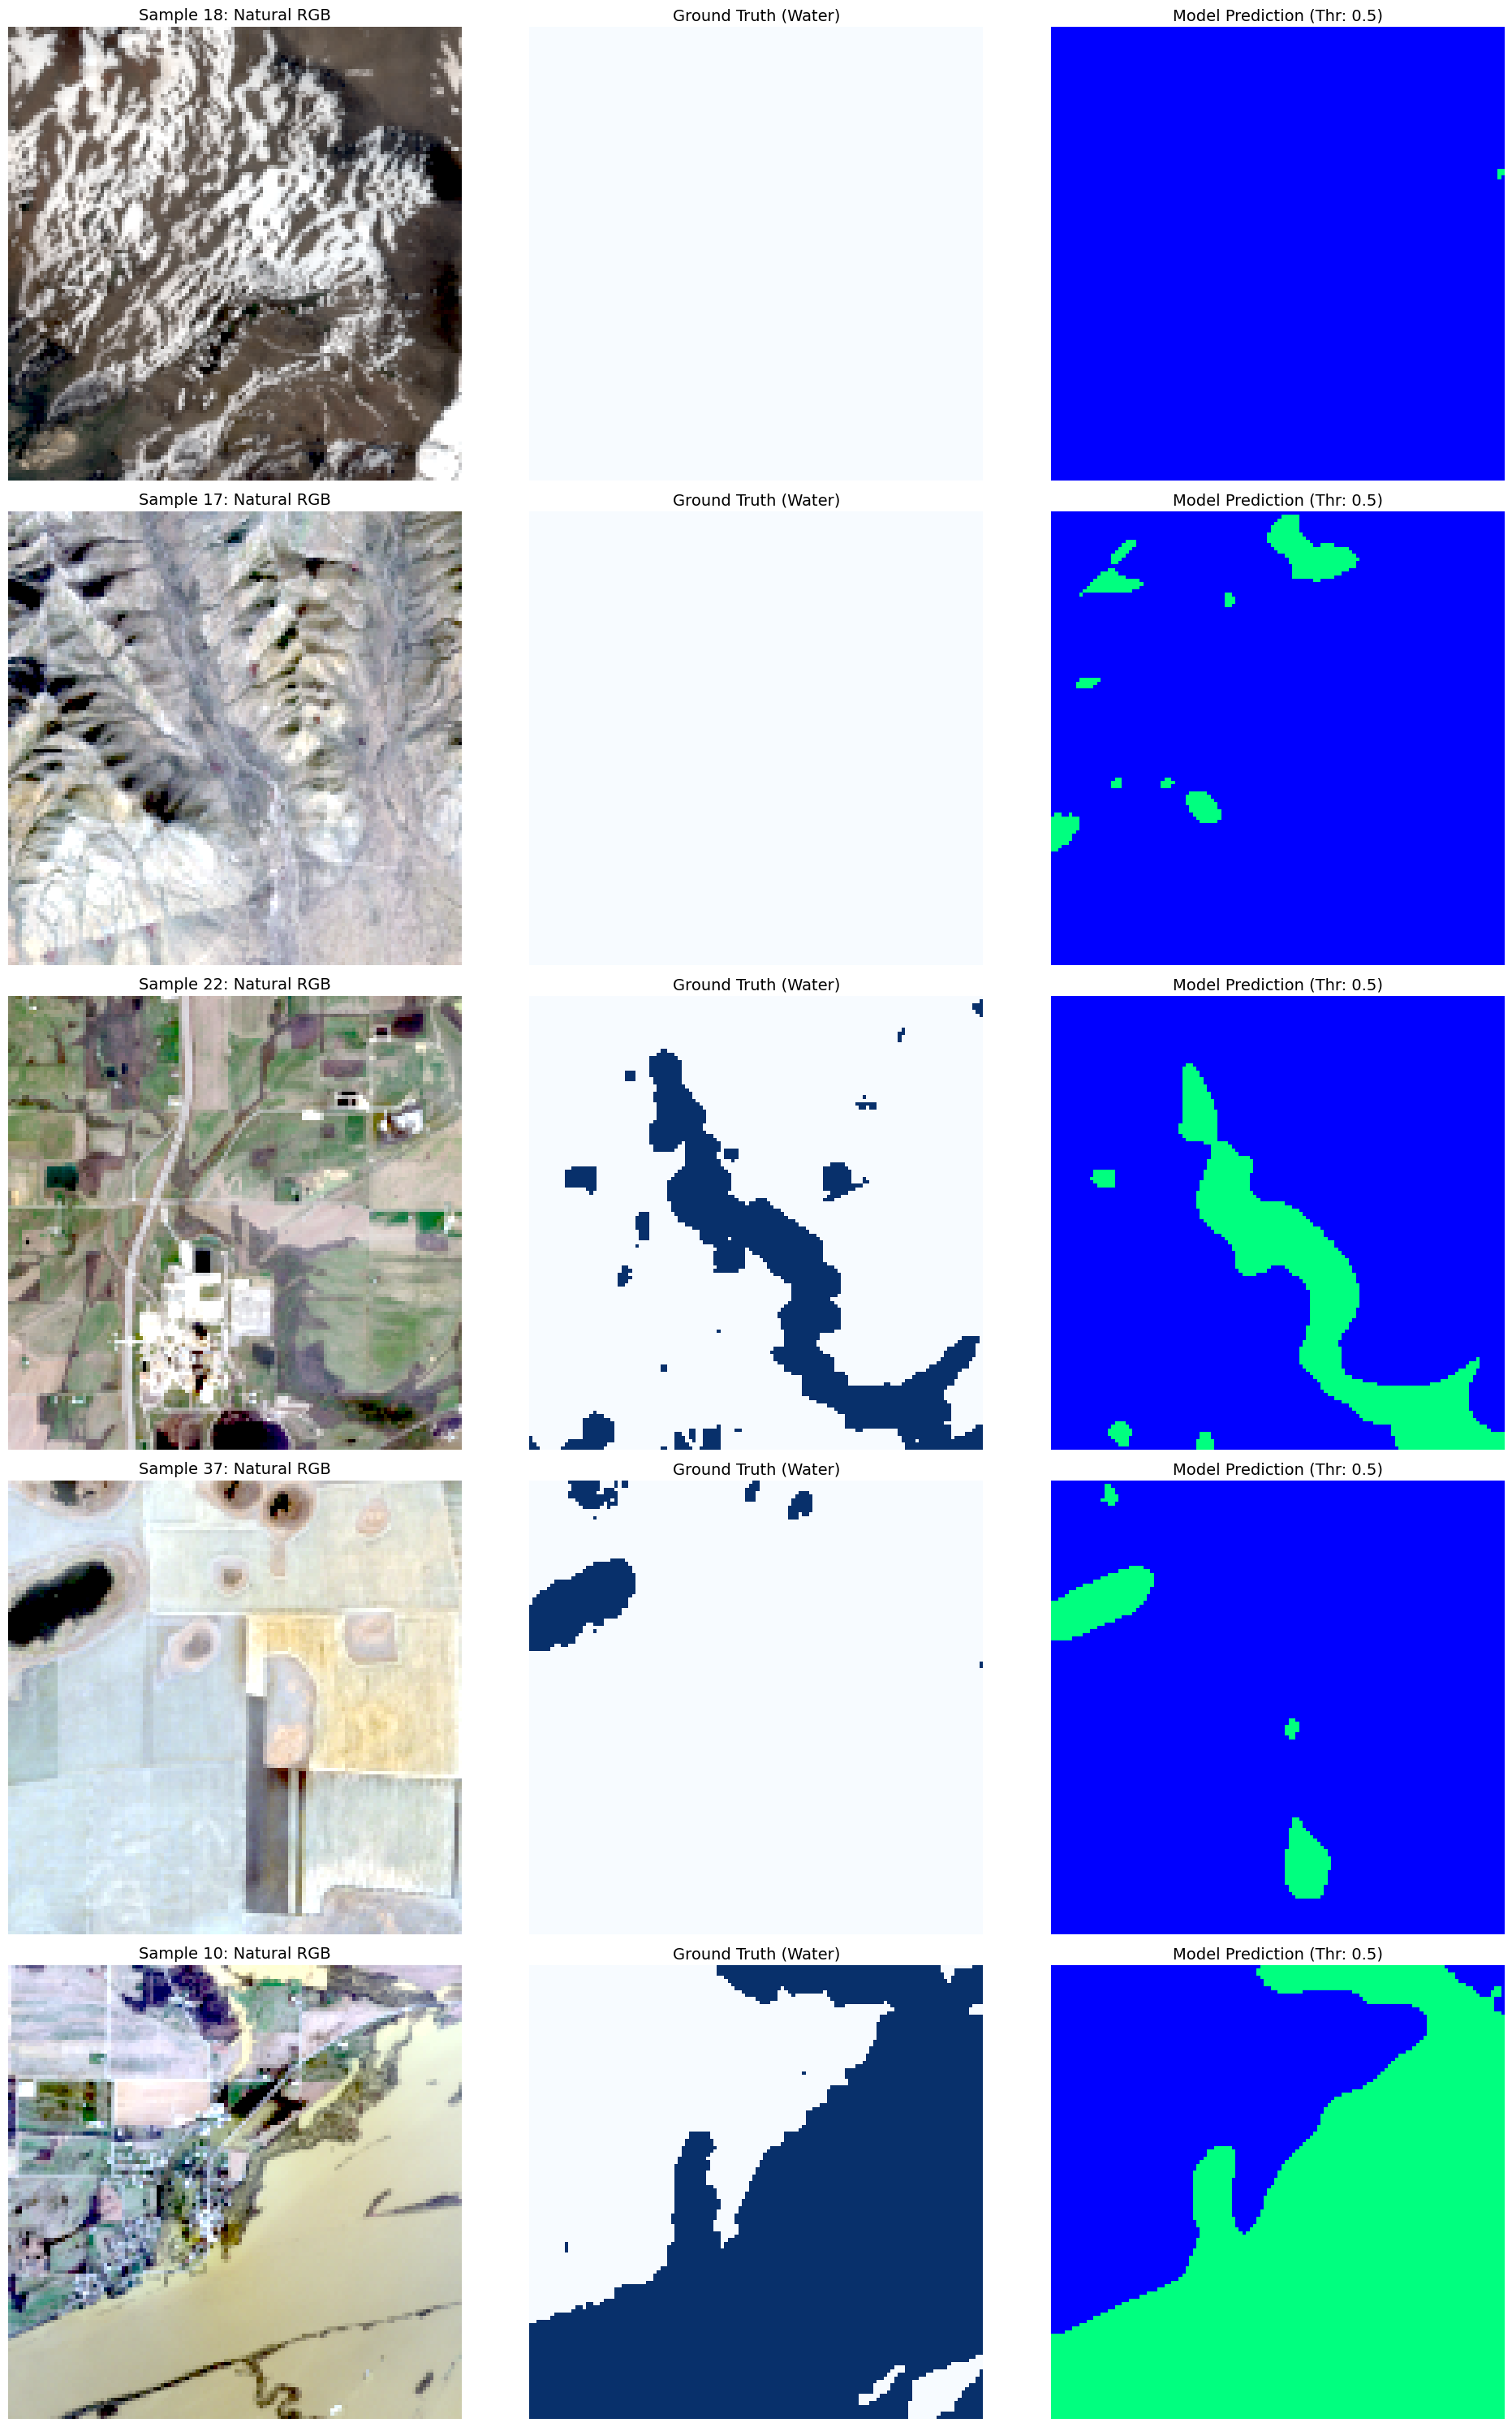

In [78]:
visualize_five_samples(
    model,
    test_data['images'],
    test_data['masks'],
    n=5,
    gamma=0.5,
    threshold=0.5
)

In [79]:
model.save('/kaggle/working/water_segmentation_vgg16_final.keras')
print("Saved.")

Saved.
